# 02 - Does Elo actually predict anything?

A rating system is only worth plotting if it forecasts results. Two checks: is Elo *calibrated* (do its probabilities match reality), and how often does the favourite actually win. The first season is dropped from every check because the ratings start cold at 1500 and need a season to settle.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from elo_ratings import data
from elo_ratings.elo import Elo
df = data.load_results()
elo = Elo().run(df)
pred = elo.predictions_frame()
pred = pred[pred.Season != '1993-94'].copy()
pred['home_pts'] = pred.FTR.map({'H':1.0,'D':0.5,'A':0.0})

## Calibration

Bucket matches by Elo's predicted home result, compare to what actually happened. On the diagonal = well calibrated.

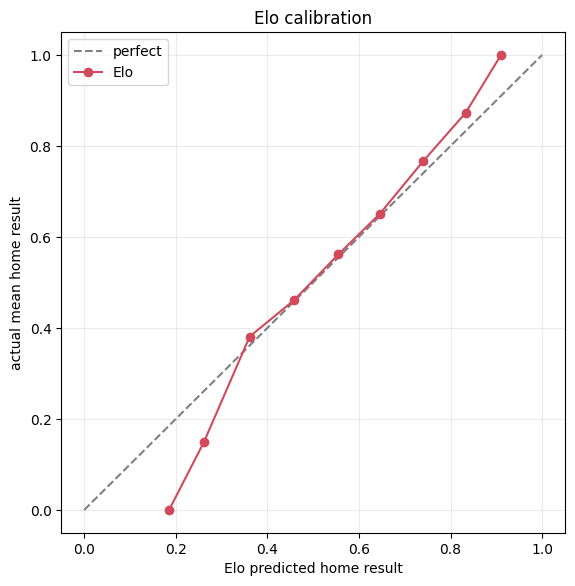

In [2]:
bins = np.linspace(0,1,11)
pred['bin'] = pd.cut(pred.p_home, bins)
cal = pred.groupby('bin', observed=True).agg(predicted=('p_home','mean'), actual=('home_pts','mean'), n=('home_pts','size')).dropna()
fig, ax = plt.subplots(figsize=(6.5,6.5))
ax.plot([0,1],[0,1],'--',color='grey',label='perfect')
ax.plot(cal.predicted, cal.actual,'o-',color='#d1495b',label='Elo')
ax.set_xlabel('Elo predicted home result'); ax.set_ylabel('actual mean home result')
ax.set_title('Elo calibration'); ax.legend(); ax.grid(alpha=.25); plt.show()

## How often does the favourite win?

In [3]:
pred['fav_home'] = pred.p_home > 0.5
fav_won = np.where(pred.fav_home, pred.FTR=='H', pred.FTR=='A')
underdog_won = np.where(pred.fav_home, pred.FTR=='A', pred.FTR=='H')
print(f'favourite won outright:   {fav_won.mean():.1%}')
print(f'draw:                     {(pred.FTR=="D").mean():.1%}')
print(f'underdog won (upset):     {underdog_won.mean():.1%}')
print(f'\nalways-home baseline:     {(pred.FTR=="H").mean():.1%}')

favourite won outright:   49.9%
draw:                     25.6%
underdog won (upset):     24.5%

always-home baseline:     46.8%


## Biggest upsets

The largest rating gaps where the favourite still lost. Almost all are Bayern defeats - unsurprising, since Bayern held by far the biggest edges, so their rare losses are the biggest surprises. Several fall on the final matchday, when a champion already crowned tends to rest players.

In [4]:
pred['diff_home'] = -400*np.log10(1/pred.p_home - 1)
pred['gap'] = pred.diff_home - elo.home_adv
pred['upset'] = np.where(pred.FTR=='A', pred.gap, np.where(pred.FTR=='H', -pred.gap, np.nan))
ups = pred.dropna(subset=['upset']).nlargest(6,'upset')
for r in ups.itertuples():
    w = r.AwayTeam if r.FTR=='A' else r.HomeTeam
    l = r.HomeTeam if r.FTR=='A' else r.AwayTeam
    print(f'{r.Date.date()} {r.Season}: {w} beat {l} (favoured by {r.upset:.0f} Elo)')

2014-04-05 2013-14: Augsburg beat Bayern Munich (favoured by 286 Elo)
2015-05-16 2014-15: Freiburg beat Bayern Munich (favoured by 273 Elo)
2013-05-18 2012-13: Hoffenheim beat Dortmund (favoured by 250 Elo)
2015-05-09 2014-15: Augsburg beat Bayern Munich (favoured by 246 Elo)
2018-05-12 2017-18: Stuttgart beat Bayern Munich (favoured by 237 Elo)
2017-02-11 2016-17: Darmstadt beat Dortmund (favoured by 233 Elo)
